In [1]:
import scipy.interpolate as interp 
try:
    import cupy as xp
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp
from scipy.signal import windows 

from Triangle.Constants import *
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.Data import *
from Triangle.TDI import *
from Triangle.GW import *
from Triangle.TDIFly import * 

# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'
import matplotlib.pyplot as plt

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


has cupy


## Settings 

In [2]:
orbit = Orbit(OrbitDir="../OrbitData/MicroSateOrbitEclipticTCB")
Tobs = YEAR
dt = 10.0
tcb_times = np.arange(int(Tobs / dt)) * dt

## Initialize response models 

### TDI-on-the-fly

In [3]:
X2_strings = TDIFly.X2_strings
Y2_strings = TDIStringManipulation.TDIStringCyc(X2_strings)
Z2_strings = TDIStringManipulation.TDIStringCyc(Y2_strings)

gb_tdifly_generator = TDIFlyGB(
    orbit=orbit, 
    Pstring_list=[X2_strings, Y2_strings, Z2_strings], 
    tcb_times=tcb_times, 
    # Nsparse=1024, 
    Nsparse=512,
    # Nsparse=256,
    # drop_points=100, 
    use_gpu=True, 
)



### original polarization-based TDI response 

In [4]:
gb_waveform_generator = GB_Injection(use_gpu=True)
gb_response_generator = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=True, 
    drop_points=100, 
    # interp_method="linear", 
    interp_method="Akima", 
)

## Source population 

In [5]:
GB_catalogue = np.load("/home/ps/workspace/TriCodes/Triangle-GB-main/Examples/BrightGBParams.npy")
GB_parameters = dict(
    A=GB_catalogue[:, 0], 
    f0=GB_catalogue[:, 1], 
    fdot0=GB_catalogue[:, 2], 
    inclination=GB_catalogue[:, 5], 
    phase0=GB_catalogue[:, 4], 
    longitude=GB_catalogue[:, 6], 
    latitude=GB_catalogue[:, 7], 
    psi=GB_catalogue[:, 8], 
)

N_GB_total = GB_catalogue.shape[0]
N_GB_total

18984

## Compare one selected source 

In [6]:
test_GB_idx = int(np.random.uniform(0, N_GB_total))
test_GB_parameters = dict()
for k, v in GB_parameters.items():
    test_GB_parameters[k] = v[test_GB_idx]
test_GB_idx, test_GB_parameters

(18840,
 {'A': 2.3500008625327206e-23,
  'f0': 0.0031185514506462497,
  'fdot0': 6.363663103084118e-17,
  'inclination': 3.351144375178435,
  'phase0': 1.408536894983507,
  'longitude': 4.69086958692519,
  'latitude': 0.005669004054088943,
  'psi': 0.3919049299176416})

In [7]:
mich_aet_td = gb_response_generator(
    parameters=test_GB_parameters, 
    waveform_generator=gb_waveform_generator, 
    optimal_combination=True, 
    )

mich_a = xp.fft.rfft(mich_aet_td[0]) * dt 
mich_e = xp.fft.rfft(mich_aet_td[1]) * dt 
freqs = xp.fft.rfftfreq(n=mich_aet_td.shape[-1], d=dt)

cut_freq_range = 5e-5 
# cut_freq_range = 3e-6
cut_freq_idx = xp.where(xp.abs(freqs-test_GB_parameters["f0"])<cut_freq_range)[0].get()
freqs = freqs[cut_freq_idx]
mich_ae = xp.array([
    mich_a[cut_freq_idx], 
    mich_e[cut_freq_idx], 
])

mich_ae.shape # (Nchannel, Nfreq)

(2, 3156)

In [8]:
test_GB_parameters_vec = dict()
for k, v in test_GB_parameters.items():
    test_GB_parameters_vec[k] = v * np.ones(1)

fly_xyz = gb_tdifly_generator(
    parameters=test_GB_parameters_vec, 
    domain="frequency"
    )
fly_aet = AETfromXYZ(fly_xyz[0], fly_xyz[1], fly_xyz[2])
fly_ae_valid = xp.array([fly_aet[0], fly_aet[1]])


fly_ae = gb_tdifly_generator.fill_fftseries(
    data=fly_ae_valid, 
    start_idx=gb_tdifly_generator.start_idx, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1],
)

# fly_ae = gb_tdifly_generator.fill_fftseries_loop(
#     data=fly_ae_valid, 
#     start_idx=gb_tdifly_generator.start_idx, 
#     StartBound=cut_freq_idx[0], 
#     EndBound=cut_freq_idx[-1],
# )

fly_ae.shape # (Nchannel, Nevent, Nfreq)

(2, 1, 3156)

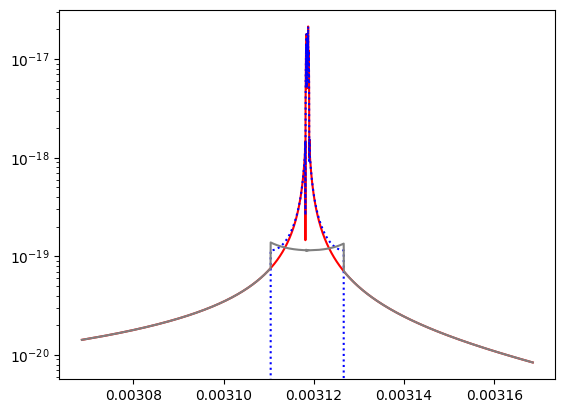

In [9]:
for ichannel, nchannel in enumerate(["A"]):
    plt.semilogy(freqs.get(), np.abs(mich_ae[ichannel].get()), color="r")
    plt.semilogy(freqs.get(), np.abs(fly_ae[ichannel][0].get()), linestyle=":", color="b")
    plt.semilogy(freqs.get(), np.abs(fly_ae[ichannel][0].get() - mich_ae[ichannel].get()), linestyle="-", color="grey")


In [10]:
def mismatch(h1, h2):
    """   
        h1: (Nchannel, Nfreq)
        h2: (Nchannel, Nevent, Nfreq)
    """
    h2_T =  xp.transpose(h2, (1, 0, 2)) # (Nevents, Nchannel, Nfreq)
    h1h2_inner = xp.real(xp.sum(xp.conjugate(h1) * h2_T, axis=(1, 2))) # (Nevents)
    h1_inner = xp.sum(xp.abs(h1) ** 2) # scalar 
    h2_inner = xp.sum(xp.abs(h2_T) ** 2, axis=(1, 2)) # (Nevent)
    return (1. - h1h2_inner / xp.sqrt(h1_inner * h2_inner)).get() # (Nevents)


In [11]:
def SNR(h, f0, Tobs): 
    """   
        h: (Nchannel=2, Nevent, Nfreq), 2 for AE
        f0: (Nevent)
        Tobs: scalar 
    """
    PSD = gb_tdifly_generator.PSD_A2(f=f0) # (Nevent)
    return xp.sqrt(4. / Tobs / PSD * xp.sum(xp.abs(h) ** 2, axis=(0, 2))) # (Nevent)


In [12]:
mismatch(mich_ae, fly_ae), 2. * 8. / SNR(fly_ae, test_GB_parameters["f0"], Tobs) ** 2 

(array([0.00148795]), array([0.01365883]))

## Compare across bright population 

In [ ]:
Ntest = 5000
MM_arr = [] 
MM_threshold_arr = [] 

# for test_GB_idx in tqdm(range(N_GB_total)):
for test_GB_idx in tqdm(range(Ntest)):
    # select source 
    test_GB_parameters = dict()
    for k, v in GB_parameters.items():
        test_GB_parameters[k] = v[test_GB_idx]

    # calculate time-domain response 
    mich_aet_td = gb_response_generator(
        parameters=test_GB_parameters, 
        waveform_generator=gb_waveform_generator, 
        optimal_combination=True, 
        )
    mich_a = xp.fft.rfft(mich_aet_td[0]) * dt 
    mich_e = xp.fft.rfft(mich_aet_td[1]) * dt 
    freqs = xp.fft.rfftfreq(n=mich_aet_td.shape[-1], d=dt)

    # slice frequency band 
    cut_freq_range = 5e-5 
    cut_freq_idx = xp.where(xp.abs(freqs-test_GB_parameters["f0"])<cut_freq_range)[0].get()
    freqs = freqs[cut_freq_idx]
    mich_ae = xp.array([
        mich_a[cut_freq_idx], 
        mich_e[cut_freq_idx], 
    ])

    # caluculate frequency-domain tdi-on-the-fly response
    test_GB_parameters_vec = dict() 
    for k, v in test_GB_parameters.items():
        test_GB_parameters_vec[k] = v * np.ones(200)
    test_GB_parameters_vec["phase0"] = np.linspace(0, TWOPI, 200)

    fly_xyz = gb_tdifly_generator(
        parameters=test_GB_parameters_vec, 
        domain="frequency"
        )
    fly_aet = AETfromXYZ(fly_xyz[0], fly_xyz[1], fly_xyz[2])
    fly_ae_valid = xp.array([fly_aet[0], fly_aet[1]]) # (2, Nevent, Nfreq)

    # fill into the same frequency band 
    fly_ae = gb_tdifly_generator.fill_fftseries(
        data=fly_ae_valid, 
        start_idx=gb_tdifly_generator.start_idx, 
        StartBound=cut_freq_idx[0], 
        EndBound=cut_freq_idx[-1],
    )

    MM_arr.append(min(mismatch(mich_ae, fly_ae)))
    MM_threshold_arr.append(float((2. * 8. / SNR(fly_ae[:, :1, :], test_GB_parameters["f0"], Tobs) ** 2)[0]))

  2%|▏         | 124/5000 [00:37<25:04,  3.24it/s]

In [ ]:
MM_arr = np.array(MM_arr)
MM_threshold_arr = np.array(MM_threshold_arr)

In [ ]:
MM_threshold_arr

array([0, 0, 0, ..., 0, 0, 0])

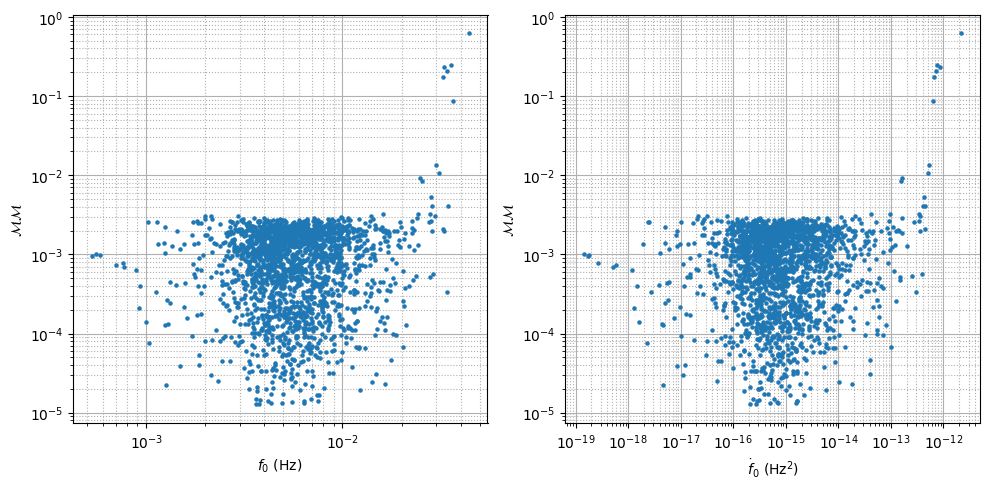

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.scatter(GB_parameters["f0"][:Ntest], MM_arr, s=5, zorder=2)
plt.xlabel(r"$f_0 \ ({\rm Hz})$")
plt.ylabel(r"$\mathcal{MM}$")
plt.xscale("log")
plt.yscale("log")
plt.grid(zorder=1, linestyle=":", which="minor")
plt.grid(zorder=1, linestyle="-", which="major")

plt.subplot(122)
plt.scatter(GB_parameters["fdot0"][:Ntest], MM_arr, s=5, zorder=2)
plt.xlabel(r"$\dot{f}_0 \ ({\rm Hz^2})$")
plt.ylabel(r"$\mathcal{MM}$")
plt.xscale("log")
plt.yscale("log")
plt.grid(zorder=1, linestyle=":", which="minor")
plt.grid(zorder=1, linestyle="-", which="major")

plt.tight_layout()

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.scatter(GB_parameters["f0"][:Ntest], np.array(MM_arr) / np.array(MM_threshold_arr), s=5, zorder=2)
plt.xlabel(r"$f_0 \ ({\rm Hz})$")
plt.ylabel(r"$\mathcal{MM} \ / \ {\rm threshold}$")
plt.xscale("log")
plt.yscale("log")
plt.grid(zorder=1, linestyle=":", which="minor")
plt.grid(zorder=1, linestyle="-", which="major")

plt.subplot(122)
plt.scatter(GB_parameters["fdot0"][:Ntest], np.array(MM_arr) / np.array(MM_threshold_arr), s=5, zorder=2)
plt.xlabel(r"$\dot{f}_0 \ ({\rm Hz^2})$")
plt.ylabel(r"$\mathcal{MM} \ / \ {\rm threshold}$")
plt.xscale("log")
plt.yscale("log")
plt.grid(zorder=1, linestyle=":", which="minor")
plt.grid(zorder=1, linestyle="-", which="major")

plt.tight_layout()

/tmp/ipykernel_46924/1318176197.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.scatter(GB_parameters["f0"][:2000], np.array(MM_arr) / np.array(MM_threshold_arr), s=5, zorder=2)
/tmp/ipykernel_46924/1318176197.py:13: RuntimeWarning: divide by zero encountered in divide
  plt.scatter(GB_parameters["fdot0"][:2000], np.array(MM_arr) / np.array(MM_threshold_arr), s=5, zorder=2)


ValueError: Data has no positive values, and therefore cannot be log-scaled.

Error in callback <function _draw_all_if_interactive at 0x78c88c3131f0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 1000x500 with 2 Axes>